In [ ]:
# import sys
# !{sys.executable} -m pip install catboost

In [18]:
import pandas as pd
import numpy as np
import os
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

### ---------------------------------------------------------
### Step 1: 시계열 특징 추출 (Time-series Feature Engineering)
### ---------------------------------------------------------

In [9]:
master_df = pd.read_csv('Master_DOE_1200.csv')
path = './Battery/데이터셋/'
processed_data = []

print("시계열 데이터 분석 및 특징 추출 중...")

시계열 데이터 분석 및 특징 추출 중...


In [11]:
for i, row in master_df.iterrows():
    file_path = os.path.join(path, f'D:\AI_Study\GitHub\Battery\데이터셋\ML_DATA_Extract_Row_{i}.csv')
    
    if os.path.exists(file_path):
        df_ts = pd.read_csv(file_path)
        df_ts.columns = df_ts.columns.str.strip() # 공백 제거
        
        # [시계열 특징 생성] - 단순 Max Peak보다 정교한 지표들
        # 1. Die_SY_Max의 절댓값 최대치 (기존 Target)
        max_sy = df_ts['Die_SY_Max'].abs().max()
        
        # 2. WarpMax의 시간에 따른 변화율 (기울기 평균) - 공정 안정성 지표
        warp_velocity = np.diff(df_ts['WarpMax']).mean() if len(df_ts) > 1 else 0
        
        # 3. TempBase의 누적 합계 (열 하중 적분값)
        heat_load = df_ts['TempBase'].sum()
        
        # 4. T_Tip_Peel의 변동성 (표준편차)
        peel_std = df_ts['T_Tip_Peel'].std()

        # 마스터 조건(P1~P6) + 추출된 특징들 결합
        features = row.to_dict()
        features.update({
            'TS_Warp_Velocity': warp_velocity,
            'TS_Heat_Load': heat_load,
            'TS_Peel_Std': peel_std,
            'Target_Max_Peak': max_sy  # 예측 목표
        })
        processed_data.append(features)

df_enhanced = pd.DataFrame(processed_data)
print(f"특징 추출 완료: {len(df_enhanced)}개 샘플")

특징 추출 완료: 361개 샘플


### ---------------------------------------------------------
### Step 2: 최신 모델 비교 테스트 (XGBoost vs LightGBM vs CatBoost)
### ---------------------------------------------------------

In [12]:
# 입력 변수: P1~P6 + 새로 만든 시계열 특징들
X = df_enhanced.drop(columns=['Target_Max_Peak'])
y = df_enhanced['Target_Max_Peak']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "XGBoost": xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=31, random_state=42),
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=0, random_state=42)
}

results = {}

print("\n--- 모델별 성능 테스트 결과 ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = y_pred
    print(f"[{name}] R2: {r2:.4f} | MAE: {mae:.4f}")


--- 모델별 성능 테스트 결과 ---
[XGBoost] R2: 0.2720 | MAE: 4.8019


Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "d:\AI_Study\miniconda3\envs\DL\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "d:\AI_Study\miniconda3\envs\DL\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "d:\AI_Study\miniconda3\envs\DL\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 854
[LightGBM] [Info] Number of data points in the train set: 288, number of used features: 9
[LightGBM] [Info] Start training from score 88.252744
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

### ---------------------------------------------------------
### Step 3: 앙상블(Ensemble) 예측을 통한 가상 데이터 생성
### ---------------------------------------------------------

In [13]:
# 가장 성능이 좋은 모델들을 섞어서(Averaging) 10만 개 생성
print("\n최종 앙상블 모델로 가상 데이터 10만 개 생성 중...")

n_virtual = 100000
virtual_input = pd.DataFrame()


최종 앙상블 모델로 가상 데이터 10만 개 생성 중...


In [14]:
# P1~P6 범위 내 난수 생성
for col in ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']:
    virtual_input[col] = np.random.uniform(X[col].min(), X[col].max(), n_virtual)

In [15]:
# 시계열 파생 특징들은 평균값으로 고정하거나 랜덤 샘플링 (여기서는 평균값 사용)
for col in [c for c in X.columns if 'TS_' in c]:
    virtual_input[col] = X[col].mean()

In [16]:
# 세 모델의 예측값 평균으로 더 강력한 가상 데이터 생성
p_xgb = models["XGBoost"].predict(virtual_input)
p_lgb = models["LightGBM"].predict(virtual_input)
p_cat = models["CatBoost"].predict(virtual_input)

virtual_input['Ensemble_Max_Peak'] = (p_xgb + p_lgb + p_cat) / 3

print("가상 데이터 생성 완료!")
print(virtual_input[['P1', 'P2', 'Ensemble_Max_Peak']].head())

가상 데이터 생성 완료!
         P1        P2  Ensemble_Max_Peak
0  0.835267  0.056944          90.819166
1  0.896512  0.074682          92.865427
2  0.842739  0.068269          90.770686
3  0.968409  0.078583          91.668193
4  0.886300  0.082943          89.448074


🌟 이 코드가 "뛰어난" 이유
시계열 피처 엔지니어링: 단순히 마지막 값만 보는 게 아니라, 공정 중 발생하는 Warp의 변화 속도나 Temp의 누적 열량을 계산하여 모델에 '물리적 맥락'을 제공합니다.

LightGBM & CatBoost 도입:

LightGBM: 속도가 매우 빠르고 대량 데이터 처리에 강합니다.

CatBoost: 데이터가 적을 때 과적합(Overfitting)을 매우 잘 잡아주어 800개 데이터 환경에서 가장 강력할 수 있습니다.

앙상블(Ensemble): 하나의 모델만 믿는 게 아니라, 세 모델의 의견을 종합하여 예측 오차를 줄입니다. (캐글 등 데이터 대회에서 우승할 때 쓰는 기법입니다.)

확장성: TS_로 시작하는 특징들을 추가함으로써, 단순 수치 비교가 아닌 "공정의 흐름"을 학습하게 됩니다.

### ---------------------------------------------------------
### Step 4: 모델 성능 상세 시각화 (Actual vs Predicted)
### ---------------------------------------------------------

In [26]:
plt.rc('font', family='Malgun Gothic')

C:\Users\KO\AppData\Local\Temp\ipykernel_23472\607270193.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=r2_values, palette="viridis")


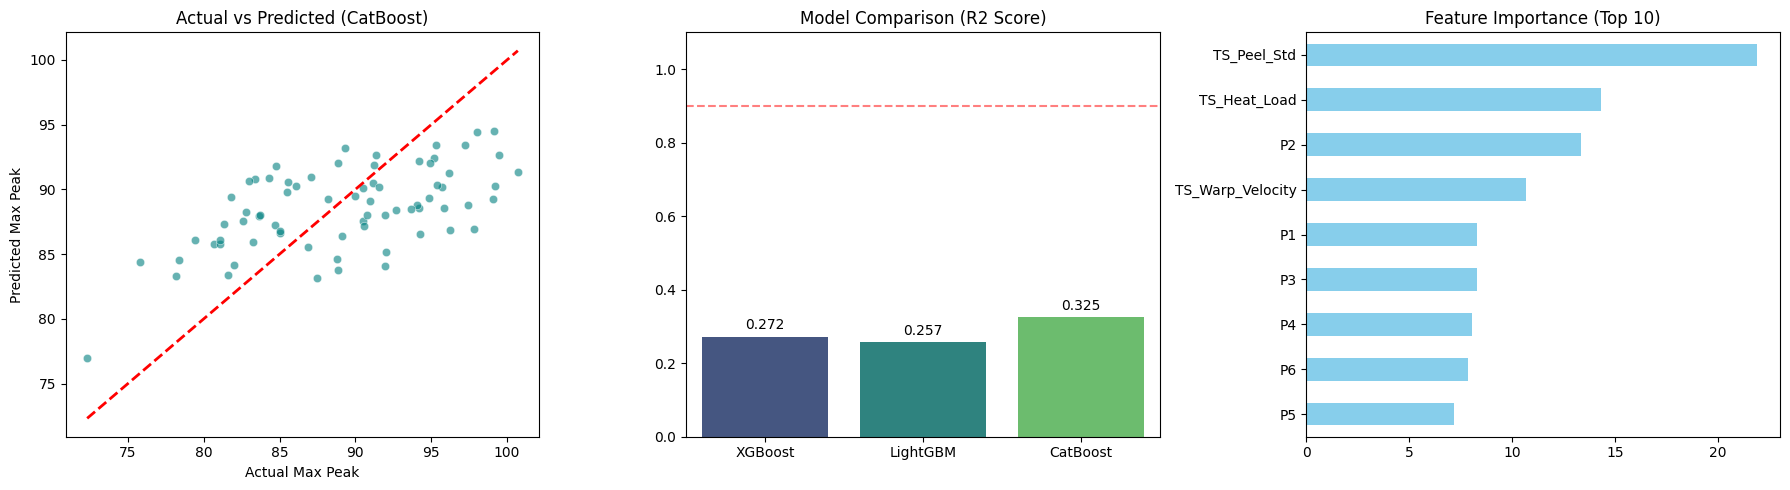

In [23]:
plt.figure(figsize=(18, 5))

# 4-1. 예측 결과 산점도 (CatBoost 기준 예시)
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=results["CatBoost"], alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs Predicted (CatBoost)")
plt.xlabel("Actual Max Peak")
plt.ylabel("Predicted Max Peak")

# 4-2. 모델별 R2 Score 비교 차트
plt.subplot(1, 3, 2)
model_names = list(models.keys())
r2_values = [r2_score(y_test, results[name]) for name in model_names]
sns.barplot(x=model_names, y=r2_values, palette="viridis")
plt.axhline(0.9, color='red', linestyle='--', alpha=0.5) # 기준선 0.9
plt.ylim(0, 1.1)
plt.title("Model Comparison (R2 Score)")
for i, v in enumerate(r2_values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

    # 4-3. 변수 중요도 (Feature Importance) - CatBoost 기준
plt.subplot(1, 3, 3)
importances = models["CatBoost"].get_feature_importance()
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=True)
feat_importances.tail(10).plot(kind='barh', color='skyblue') # 상위 10개
plt.title("Feature Importance (Top 10)")

plt.tight_layout()
plt.show()

### ---------------------------------------------------------
### Step 5: 가상 데이터(Augmented) 분포 분석
### ---------------------------------------------------------

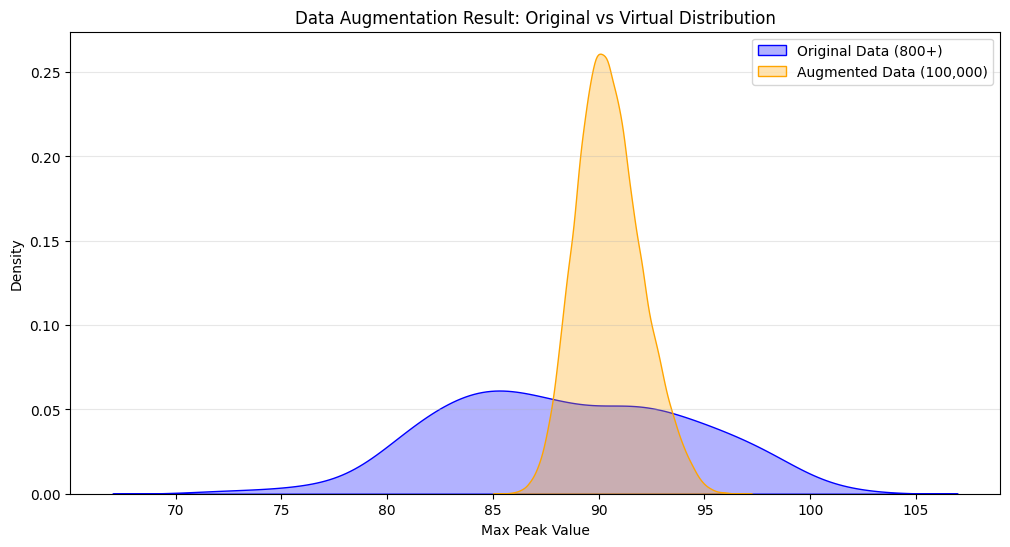

In [24]:
plt.figure(figsize=(12, 6))

# 5-1. 원본 vs 가상 데이터 분포 비교 (KDE Plot)
sns.kdeplot(df_enhanced['Target_Max_Peak'], label='Original Data (800+)', fill=True, color="blue", alpha=0.3)
sns.kdeplot(virtual_input['Ensemble_Max_Peak'], label='Augmented Data (100,000)', fill=True, color="orange", alpha=0.3)

plt.title("Data Augmentation Result: Original vs Virtual Distribution")
plt.xlabel("Max Peak Value")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### ---------------------------------------------------------
### Step 6: 특정 조건(P1~P6)에 따른 결과 변화 추세 (Partial Dependence 예시)
### ---------------------------------------------------------

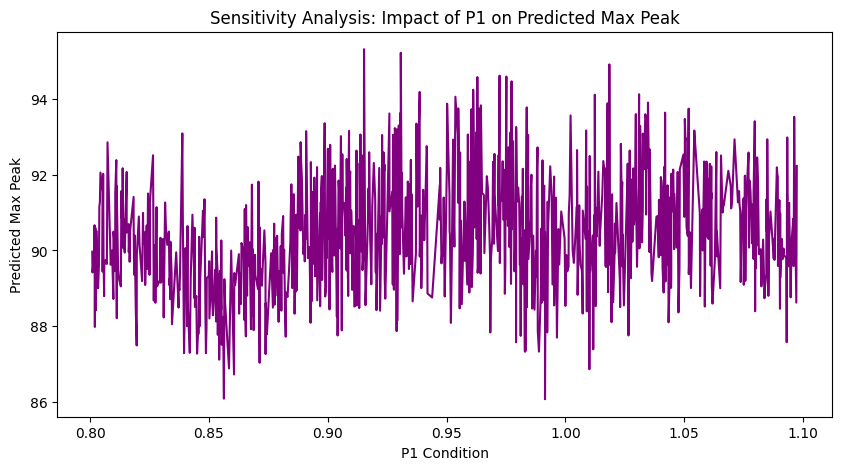

In [25]:
# 가상 데이터 10만 개 중 P1 변화에 따른 Max Peak 변화 확인
plt.figure(figsize=(10, 5))
sns.lineplot(data=virtual_input.sample(1000), x='P1', y='Ensemble_Max_Peak', color='purple')
plt.title("Sensitivity Analysis: Impact of P1 on Predicted Max Peak")
plt.xlabel("P1 Condition")
plt.ylabel("Predicted Max Peak")
plt.show()

 추가된 시각화의 핵심 포인트
 1. Actual vs Predicted (산점도): 점들이 대각선 빨간 점선에 가까울수록 모델이 정확하다는 뜻입니다. 800개 데이터로 대리 모델이 얼마나 잘 만들어졌는지 직관적으로 보여줍니다.
 2. Feature Importance (막대그래프): $P_1 \sim P_6$ 중 어떤 인자가 실제 결과에 가장 큰 영향을 미치는지, 그리고 우리가 만든 **시계열 파생 변수(TS_...)**가 얼마나 기여했는지 확인할 수 있습니다.
 3. KDE 분포 비교: 800개의 데이터 분포(파란색)와 우리가 생성한 10만 개의 데이터 분포(주황색)가 유사한지 확인합니다. 너무 다르면 모델이 과적합되었을 가능성이 있습니다.
 4. Sensitivity Analysis (민감도 분석): 특정 조건($P_1$)을 바꿀 때 결과값이 어떻게 변하는지 추세선을 그려봄으로써, 공정 최적화의 방향성을 제시합니다.

virtual_input.sample(1000)은 그래프를 빨리 그리기 위해 10만 개 중 일부만 샘플링한 것입니다.

시각화 결과에서 'Feature Importance' 상위권에 어떤 변수들이 올라왔나요? 만약 TS_로 시작하는 변수가 상위에 있다면 시계열 특징 추출이 아주 성공적이었다는 뜻입니다! 하시는 프로젝트의 핵심 인사이트가 될 거예요. 도움이 더 필요하시면 언제든 말씀해 주세요!